In [2]:
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm

In [3]:
dirs = ["aggregated_tfbs", "biomart", "cpg_islands_ucsc_hgtables", "genome_wide"]
motif_files = glob("./extracted_features/aggregated_tfbs/*_EM.csv")

df = pd.read_csv(f"./extracted_features/{dirs[0]}/{motif_files[0].split('/')[-1]}", index_col=0)
# rename s3 to s3_tfbs
df.rename(columns={"s3": "s3_tfbs"}, inplace=True)
for dir in dirs[1:]:
    print(dir)
    temp_df = pd.read_csv(f"./extracted_features/{dir}/{motif_files[0].split('/')[-1]}", index_col=0)
    df[f"s3_{dir}"] = temp_df["s3"]

# Divide all columns by the sum to get the percentage
df_relative = df.copy()
for col in df_relative.columns:
    if col.startswith("s3_"):
        df_relative[col] = df_relative[col] / df_relative[col].sum()

biomart
cpg_islands_ucsc_hgtables
genome_wide


100%|██████████| 4/4 [00:00<00:00, 2946.99it/s]


                               s3_tfbs  s3_biomart  \
s3_tfbs                       0.000000    0.039819   
s3_biomart                    0.039819    0.000000   
s3_cpg_islands_ucsc_hgtables  0.054279    0.035188   
s3_genome_wide                0.210383    0.225546   

                              s3_cpg_islands_ucsc_hgtables  s3_genome_wide  
s3_tfbs                                           0.054279        0.210383  
s3_biomart                                        0.035188        0.225546  
s3_cpg_islands_ucsc_hgtables                      0.000000        0.246020  
s3_genome_wide                                    0.246020        0.000000  


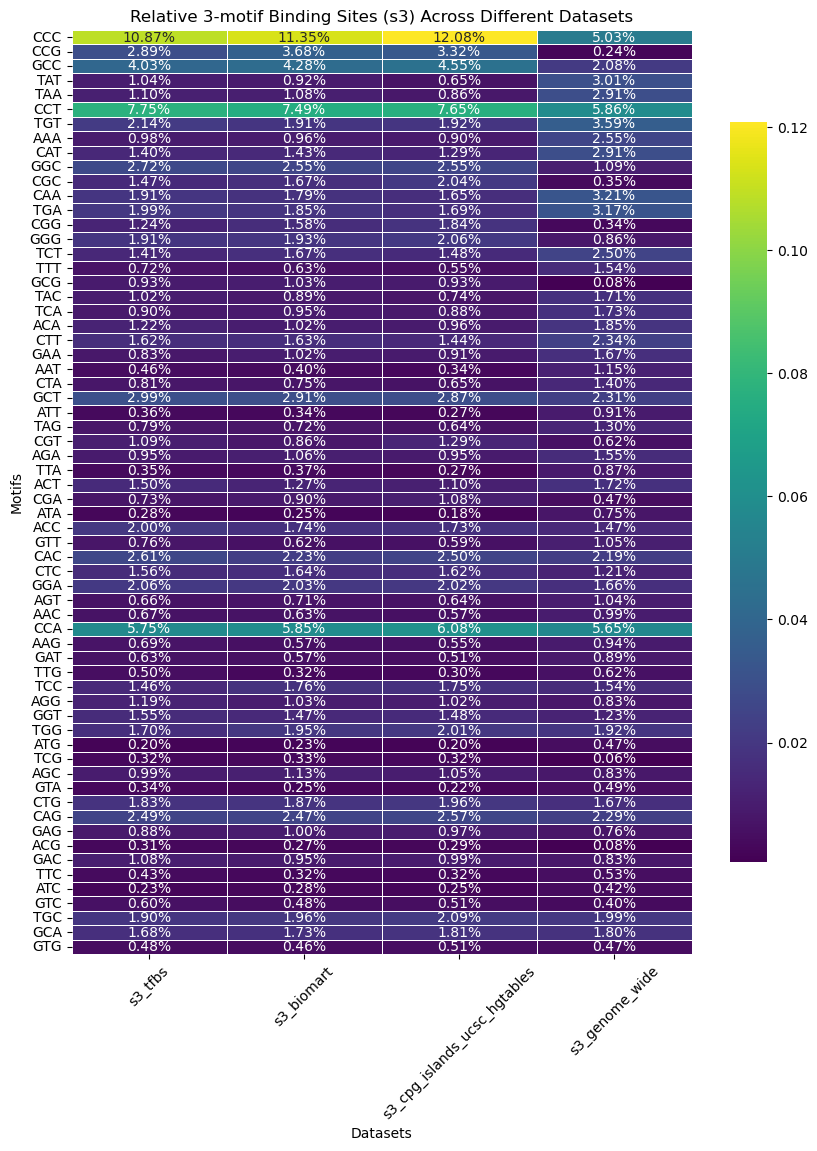

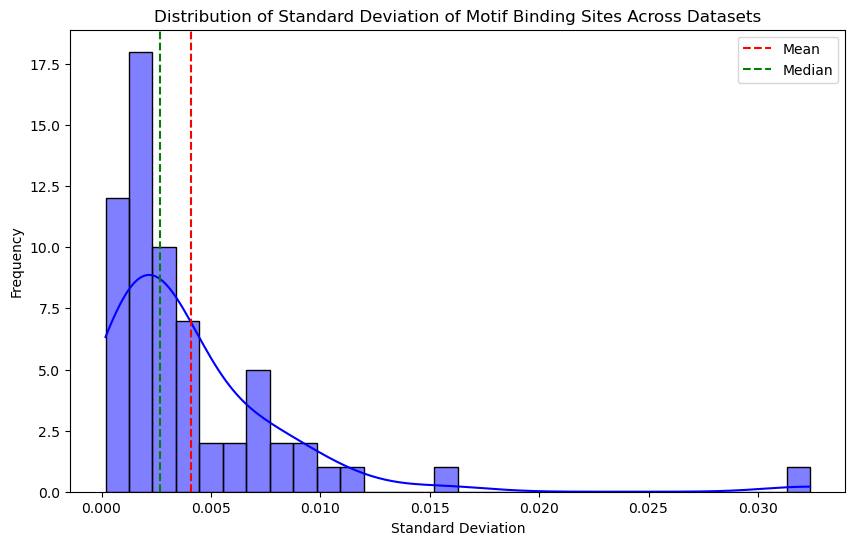

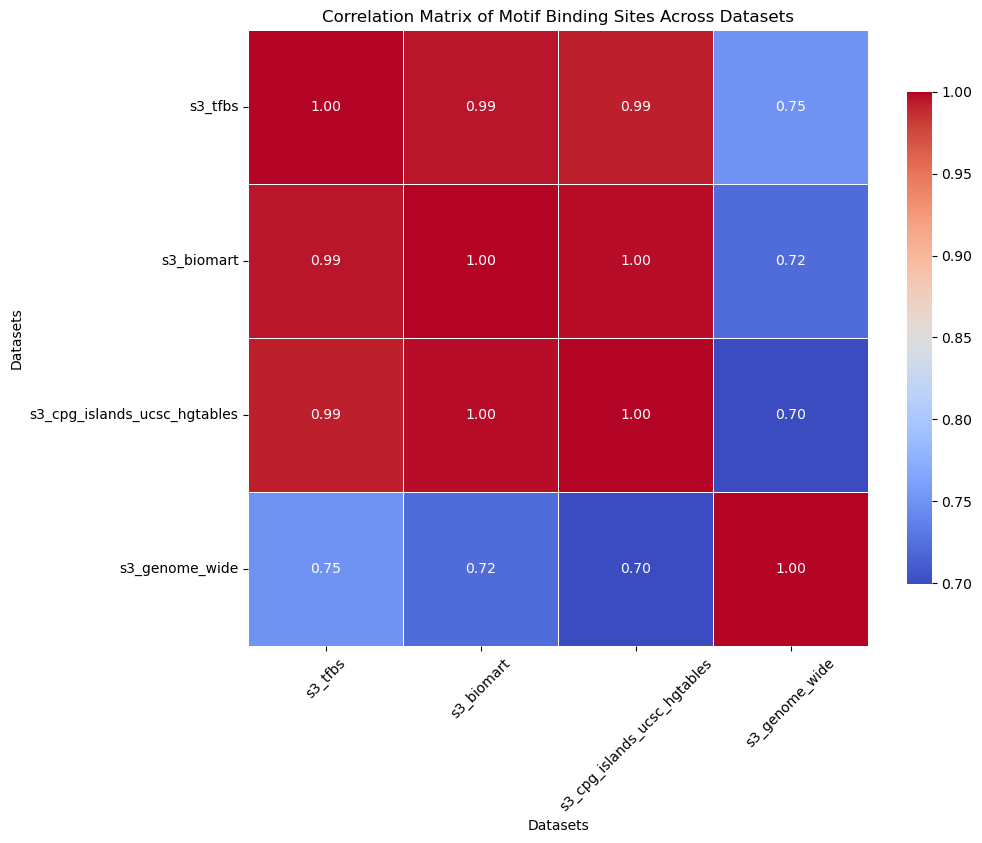

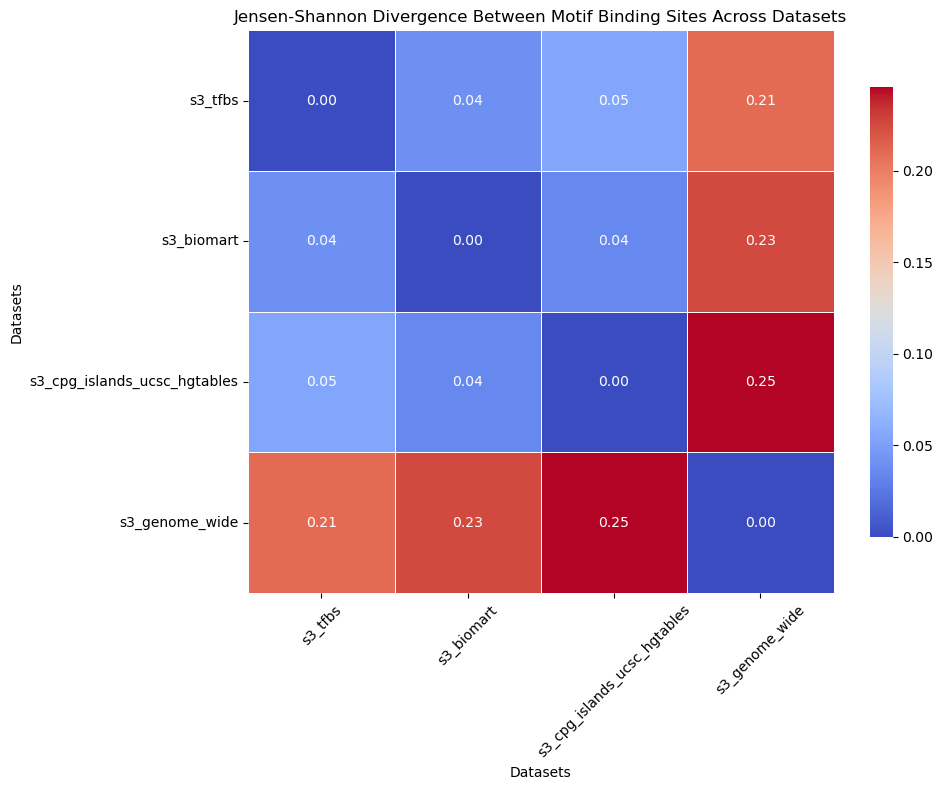

In [4]:
# Plot a heatmap of the relative values
# Calculate the standard deviation for each motif across datasets
std_dev = df_relative.std(axis=1)
# Sort the DataFrame by the standard deviation
sorted_indices = std_dev.sort_values(ascending=False).index
df_relative = df_relative.loc[sorted_indices]

plt.figure(figsize=(10, 12))
sns.heatmap(df_relative, cmap="viridis", annot=True, fmt=".2%", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Relative 3-motif Binding Sites (s3) Across Different Datasets")
plt.xlabel("Datasets")
plt.ylabel("Motifs")
plt.xticks(rotation=45)

# Add the sd to the plot as a distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(std_dev, kde=True, color="blue", bins=30)
plt.title("Distribution of Standard Deviation of Motif Binding Sites Across Datasets")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")
plt.axvline(std_dev.mean(), color="red", linestyle="--", label="Mean")
plt.axvline(std_dev.median(), color="green", linestyle="--", label="Median")
plt.legend()


# Calculate the correlation matrix between the columns
correlation_matrix = df_relative.corr(method="pearson")
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Motif Binding Sites Across Datasets")
plt.xlabel("Datasets")
plt.ylabel("Datasets")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# What is the jensen-shannon divergence between the columns?
js_divergence = pd.DataFrame(index=df_relative.columns, columns=df_relative.columns)
for col1 in tqdm(df_relative.columns):
    for col2 in df_relative.columns:
        if col1 != col2:
            js_divergence.loc[col1, col2] = jensenshannon(df_relative[col1], df_relative[col2])
        else:
            js_divergence.loc[col1, col2] = 0.0

js_divergence.fillna(0, inplace=True)
js_divergence = js_divergence.astype(float)
print(js_divergence)

plt.figure(figsize=(10, 8))
sns.heatmap(js_divergence, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Jensen-Shannon Divergence Between Motif Binding Sites Across Datasets")
plt.xlabel("Datasets")
plt.ylabel("Datasets")
plt.xticks(rotation=45)
plt.yticks(rotation=0)


plt.tight_layout()
plt.show()